In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [25]:
!git --version

git version 2.34.1


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
!ls /content/drive/MyDrive/telco_churn.csv

/content/drive/MyDrive/telco_churn.csv


In [28]:
df = pd.read_csv("/content/drive/MyDrive/telco_churn.csv")

In [29]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4969,2303-PJYHN,Female,0,Yes,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Bank transfer (automatic),19.85,52,No
1922,8201-AAXCB,Male,0,Yes,Yes,25,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,No,Electronic check,60.35,1404.65,No
388,8782-LKFPK,Male,0,No,No,44,Yes,Yes,Fiber optic,No,...,Yes,No,No,Yes,Month-to-month,Yes,Mailed check,90.40,4063,No
6092,4024-CSNBY,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Bank transfer (automatic),94.25,6849.75,No
3136,3884-HCSWG,Female,0,No,No,17,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.00,1144.5,Yes


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [31]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [32]:
print(df.duplicated().sum())

0


In [33]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)

In [34]:
# analysing statistical values
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [35]:
# drop the 'customerID' column as it does not has any significance in analysis and model training.

df.drop('customerID', axis = 1, inplace = True)

In [36]:
# segregating numerical and categorical features.

num_cols = df.select_dtypes(include = ['float64','int64']).columns
cat_cols = df.select_dtypes(include = ['object']).columns

print("Numerical Features:", num_cols)
print("Categorical Features:", cat_cols)

Numerical Features: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')
Categorical Features: Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


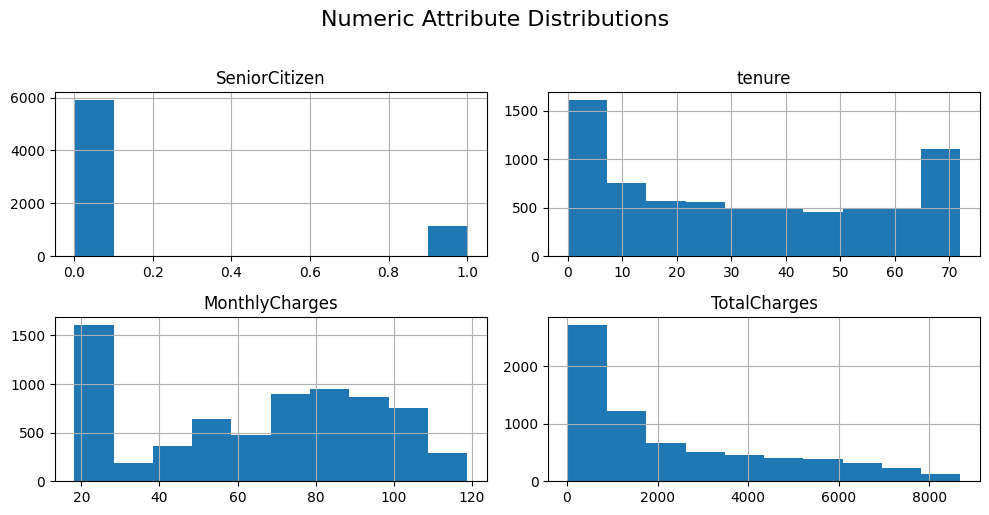

In [37]:
# Analysing distribution of numerical values.

df[num_cols].hist(figsize = (10,5))
plt.suptitle("Numeric Attribute Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

1. Number of senior citizens are fewer.
2. Tunure of the telco service vary between 0 to 70.
3. Monthly charges vary person to person.
4. Majority of the people pay less than 4000 Total charges.

In [38]:
# Finding Unique values of the categorical features so that encoding can be done correctly.

for col in cat_cols:
 print(col,  df[col].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn ['No' 'Yes']


<Axes: xlabel='Churn', ylabel='tenure'>

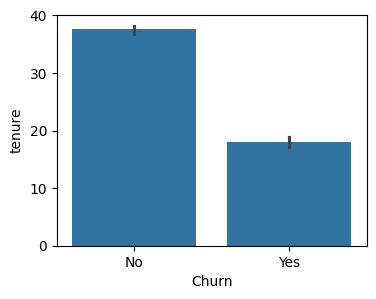

In [39]:
plt.figure(figsize = (4,3))
sns.barplot(data = df, y = 'tenure', x = 'Churn' )

Those who are using service of long tenure churn less.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

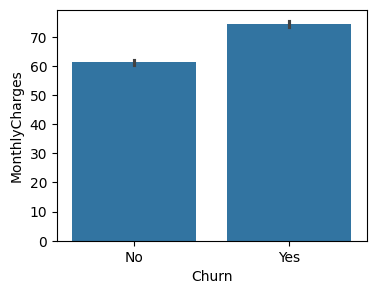

In [40]:
plt.figure(figsize = (4,3))
sns.barplot(data = df, y = 'MonthlyCharges', x = 'Churn' )

Those who pay high monthly charges have high probability to churn.

<Axes: xlabel='Churn', ylabel='count'>

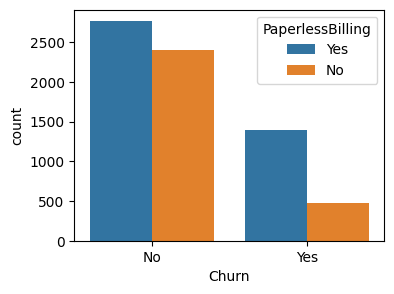

In [41]:
plt.figure(figsize = (4,3))
sns.countplot(data =df, x ='Churn', hue = 'PaperlessBilling')

Those who take hard copy of the bill quit the service less.

<Axes: xlabel='Churn', ylabel='count'>

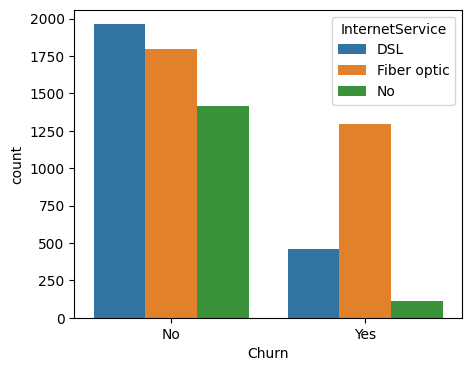

In [42]:
plt.figure(figsize = (5,4))
sns.countplot(data =df, x = 'Churn', hue = 'InternetService')

Customers who use DSL are the most stable. Customers who use Fiber optic have the high probability of Churn, While those who have no internet connection churn the least, parheps because of no dependency on the internet.

There is no syntax issue, and we don't need to convert capital letters into small letters or vice versa.

In [43]:
# Applying OneHot encoding on categorical features.

df = pd.get_dummies(df, columns = cat_cols, drop_first = True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


We have encoded the categorical features. Now we will scale the numerical features so that no feature could create unnecessary bias in classification.

In [44]:
# Scaling numerical features using z- standardisation as it is robust to outliers.
# Although we have not found major issue of outliers, yet we will use z-standardisation for scaling.

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,-0.439916,-1.277445,-1.160323,-0.994194,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,-0.439916,0.066327,-0.259629,-0.173740,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,-0.439916,-1.236724,-0.362660,-0.959649,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,-0.439916,0.514251,-0.746535,-0.195248,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,-0.439916,-1.236724,0.197365,-0.940457,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


Now all the values of features are in the range of 0 - 1, and all features will have equal say in classification.

In [45]:
!git config --global user.name padhanaya
!git config --global user.email sachinpadhanaya@gmail.com

In [47]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [48]:
!ls

'2025EM1100450_SMI_Assignment1_ipynb (1) (1).ipynb'
'2025EM1100450_SMI_Assignment1_ipynb (1).ipynb'
 2025EM1100450_SMI_Assignment1.ipynb.ipynb
 ANN.ipynb
'Apex 1-Real Estate.ipynb'
 apex_project.ipynb
 assignment.ipynb
 Codeblocks_with_results_jupyter.ipynb
'Copy of ANN.ipynb'
'Copy of apex_project4.ipynb'
'Copy of data_quality.ipynb'
'Copy of intern.ipynb'
'Copy of Lab_pandas.ipynb'
'data cleaning missing values lab (1).ipynb'
'data cleaning missing values lab.ipynb'
 DVS_matplotlib1.ipynb
'FE_Assignment (1).ipynb'
'FE_Assignment_2025EM1100450 (1).ipynb.ipynb'
'FE_Assignment_2025EM1100450_ipynb (1).ipynb'
'FE_Assignment_2025EM1100450_ipynb (2).ipynb'
 FE_Assignment_2025EM1100450.ipynb.ipynb
 FE_Assignment_2025EM1100450_ipynb.ipynb
'FE_Assignment (2).ipynb'
 FE_Assignment.ipynb
'House_Predict (1).ipynb'
 House_Predict.ipynb
 House_Predict_ML1.ipynb
'House_Predict_ML_Final (1).ipynb'
 House_Predict_ML_Final.ipynb
 intern.ipynb
'Lab 2.2_ Introduction to pandas and matplotlib.ipynb'
'lab3

In [49]:
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/Colab Notebooks/.git/


In [50]:
!git add Copy of ANN.ipynb

fatal: pathspec 'Copy' did not match any files
